<a href="https://colab.research.google.com/github/xcl-esc/Analise_Airbnb/blob/main/machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd /content/drive/MyDrive/analise_de_dados/Testes

/content/drive/MyDrive/analise_de_dados/Testes


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np

In [4]:
df = pd.read_csv('dados_limpos.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19427 entries, 0 to 19426
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      19427 non-null  int64  
 1   listing_url             19427 non-null  object 
 2   scrape_id               19427 non-null  int64  
 3   last_scraped            19427 non-null  object 
 4   name                    19427 non-null  object 
 5   description             18971 non-null  object 
 6   host_since              18700 non-null  object 
 7   latitude                19427 non-null  float64
 8   longitude               19427 non-null  float64
 9   room_type               19427 non-null  object 
 10  accommodates            19427 non-null  int64  
 11  bathrooms               19427 non-null  float64
 12  bedrooms                19427 non-null  float64
 13  beds                    19427 non-null  float64
 14  price                   19427 non-null

In [5]:
df[['latitude', 'longitude']]

,latitude,longitude
0,-22.966350,-43.179380
1,-22.945330,-43.181630
2,-22.937220,-43.696646
3,-22.981652,-43.223144
4,-22.983108,-43.202661
...,...,...
19422,-22.969300,-43.190260
19423,-22.982983,-43.194528
19424,-22.981750,-43.192860
19425,-22.975900,-43.193660


In [6]:
df_colunas = [
    'latitude', 'longitude', 'price', 'bedrooms', 'bathrooms',
    'accommodates', 'beds', 'room_type'
]
df_cluster = df[df_colunas].copy()
df_cluster = pd.get_dummies(df_cluster, columns=['room_type'])

In [7]:
scaler = StandardScaler()
df_1_0 = scaler.fit_transform(df_cluster)
df_1_0 = pd.DataFrame(df_1_0, columns=df_cluster.columns)

df_1_0.head()

,latitude,longitude,price,bedrooms,bathrooms,accommodates,beds,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,-0.009162,0.691274,-0.061216,0.493276,-0.504545,0.448773,0.781087,0.492476,-0.020297,-0.478634,-0.091986
1,0.577990,0.668707,-0.161145,-0.514493,-0.504545,-0.854737,-0.642560,0.492476,-0.020297,-0.478634,-0.091986
2,0.804532,-4.496827,-0.203923,0.493276,-0.504545,0.014269,0.781087,0.492476,-0.020297,-0.478634,-0.091986
3,-0.436588,0.252330,0.028447,0.493276,0.532627,0.448773,0.306538,0.492476,-0.020297,-0.478634,-0.091986
4,-0.477264,0.457772,-0.114603,-0.514493,0.014041,0.014269,-0.168011,0.492476,-0.020297,-0.478634,-0.091986


In [8]:
df_1_0.tail()

,latitude,longitude,price,bedrooms,bathrooms,accommodates,beds,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
19422,-0.091565,0.582150,-0.121447,-0.514493,-0.504545,-0.854737,-0.642560,-2.030555,-0.020297,2.089280,-0.091986
19423,-0.473767,0.539345,-0.114945,-0.514493,-0.504545,-0.420234,-0.168011,0.492476,-0.020297,-0.478634,-0.091986
19424,-0.439331,0.556072,-0.067376,-0.514493,0.532627,-0.420234,-0.168011,0.492476,-0.020297,-0.478634,-0.091986
19425,-0.275923,0.548048,-0.186812,-0.514493,-0.504545,-0.854737,-0.168011,-2.030555,-0.020297,2.089280,-0.091986
19426,1.296148,0.626682,0.688253,4.524355,4.162729,5.228308,6.475671,0.492476,-0.020297,-0.478634,-0.091986


In [10]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(df_1_0)
df['dbscan_cluster'] = clusters
print(df['dbscan_cluster'].value_counts())

dbscan_cluster
 1     7138
-1     3198
 4     2299
 2     1235
 0      825
       ... 
 60       4
 82       4
 52       4
 88       4
 74       3
Name: count, Length: 95, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

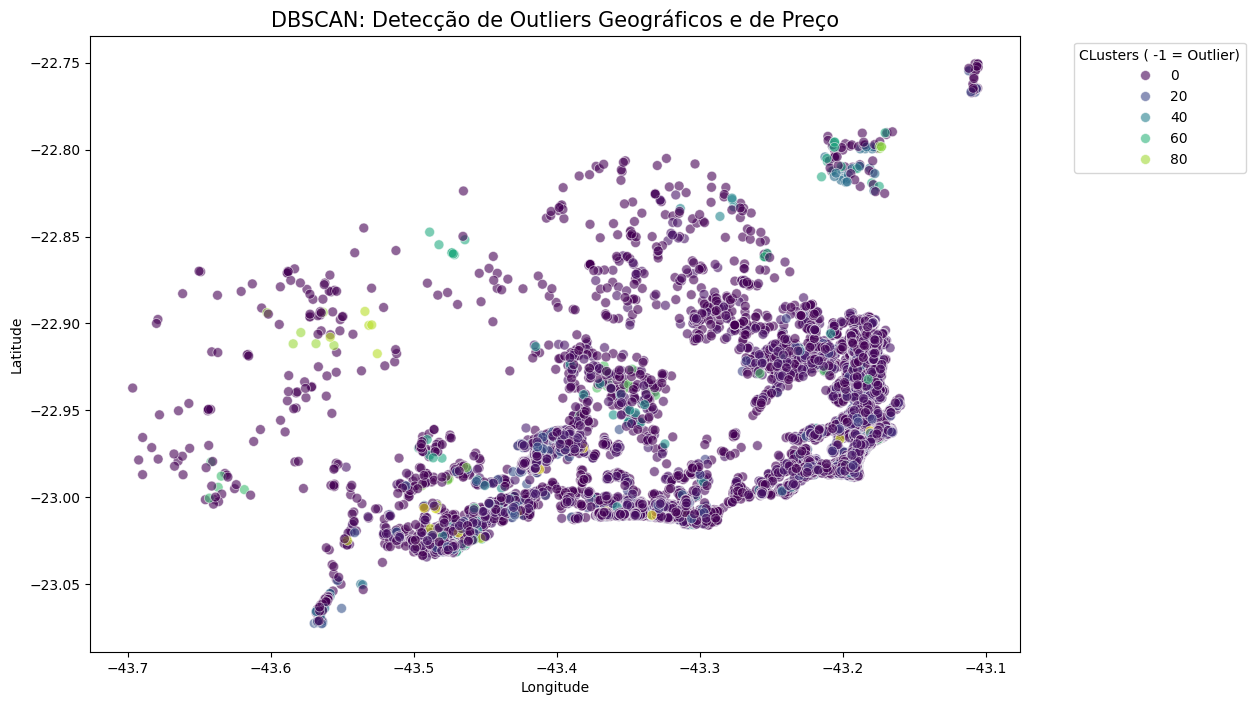

In [13]:
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=df, x='longitude', y='latitude',
    hue='dbscan_cluster', palette='viridis',
    alpha=0.6, s=50
)
plt.title('DBSCAN: Detecção de Outliers Geográficos e de Preço', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.legend(title='CLusters ( -1 = Outlier)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show